# Exploration of Machine Learning Algorithms for Predicting Dissolved Organic Content in Lakes (Landsat 8)

In [53]:
import matplotlib.font_manager as fm
import matplotlib as plt

available_fonts = sorted({f.name for f in fm.fontManager.ttflist})
plt.rcParams['font.family'] = 'Garamond'
plt.rcParams['font.size'] = 11.5 

## Data Pre-processing

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import ee
import geemap
Map= geemap.Map()

### In-situ Measurements

In [55]:
ltm_file = pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\LTM_Data_2023_3_9.xlsx")

water_chemistry_cols = [
    'ANC_UEQ_L', 'CA_UEQ_L', 'CHL_A_UG_L', 'CL_UEQ_L', 'COLOR_APP_PTCO',
    'COLOR_TRU_PTCO', 'COND_US_CM', 'F_UEQ_L', 'K_UEQ_L',
    'MG_UEQ_L', 'NA_UEQ_L', 'NH4_UEQ_L', 'NO3_UEQ_L', 'N_TD_UEQ_L', 'PH_EQ',
    'PH_FLD', 'PH_LAB', 'PH_STVL', 'P_TL_UEQ_L', 'SECCHI_M', 'SIO2_MG_L',
    'SO4_UEQ_L', 'WTEMP_DEG_C', 'month', 'TIME_SMP', 'SAMPLE_TYPE'
]

ltm_file = ltm_file.drop(columns=water_chemistry_cols)
ltm_file = ltm_file[ltm_file['SAMPLE_LOCATION'] == 'EPI']
ltm_file = ltm_file.drop(columns=['SAMPLE_LOCATION'])
ltm_file = ltm_file[ltm_file['PROGRAM_ID'] == 'LTM_ALTM']
ltm_file = ltm_file.drop(columns=['PROGRAM_ID'])
ltm_file = ltm_file.dropna(subset=['SAMPLE_DEPTH'])
ltm_file['DOC_MG_L'] = ltm_file.groupby('SITE_ID')['DOC_MG_L'].transform(
    lambda x: x.fillna(x.mean())
) # for missing DOC values
ltm_file = ltm_file.sort_values(by='DATE_SMP', ascending=True)

ltm_file

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L
16466,1A2-028,1992-06-08,Lake,0.0,6.0110
18694,1A1-102,1992-06-08,Lake,0.0,5.4140
31710,020188,1992-06-08,Lake,0.5,5.7600
23215,020197,1992-06-08,Lake,0.5,5.2010
20774,020138,1992-06-08,Lake,0.0,10.8910
...,...,...,...,...,...
3121,04253635,2021-09-27,Stream,0.0,9.9095
17747,1A1-017,2021-09-27,Lake,0.0,9.8247
3119,04253630,2021-09-27,Stream,0.0,8.7181
10439,1A1-111,2021-09-27,Lake,0.0,12.2881


In [56]:
print("ltm_file:", ltm_file.columns)


ltm_file: Index(['SITE_ID', 'DATE_SMP', 'WATERBODY_TYPE', 'SAMPLE_DEPTH', 'DOC_MG_L'], dtype='object')


In [57]:
ltm_file.isna().sum()

SITE_ID           0
DATE_SMP          0
WATERBODY_TYPE    0
SAMPLE_DEPTH      0
DOC_MG_L          0
dtype: int64

In [58]:
ltm_file['SITE_ID'].nunique()

59

In [59]:
site_info_file = pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\Site_Information_2022_8_1.xlsx")

selected_features = [
    'SITE_ID', 'PROGRAM_ID', 'SITE_NAME', 
    'LATDD', 'LONDD', 'LATDD_CENTROID', 'LONDD_CENTROID',
    'ECOREGION_IV',
    'ECONAME_IV',
    'LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN',
    'LAKE_AREA_HA',
    'WSHD_AREA_HA', 'SITE_ELEV',
    'WSHD_ELEV_AVG',
    'WSHD_SLOPE_AVG'
]
#  'WSHD_ELEV_MIN', 'WSHD_ELEV_MAX'

site_info_file = site_info_file[selected_features]
site_info_file = site_info_file[site_info_file['PROGRAM_ID'] == 'LTM_ALTM']
site_info_file['LATDD_CENTROID'] = site_info_file['LATDD_CENTROID'].fillna(site_info_file['LATDD'])
site_info_file['LONDD_CENTROID'] = site_info_file['LONDD_CENTROID'].fillna(site_info_file['LONDD'])
site_info_file = site_info_file.drop(columns=['LATDD'])
site_info_file = site_info_file.drop(columns=['LONDD'])
# site_info_file = site_info_file.dropna(subset=['LAKE_DEPTH_MEAN'])
site_info_file = site_info_file.drop(columns=['PROGRAM_ID'])
for col in ['LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN', 'LAKE_AREA_HA', 'WSHD_AREA_HA', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG']:
    site_info_file[col] = site_info_file.groupby('ECOREGION_IV')[col].transform(lambda x: x.fillna(x.median()))

site_info_file
# print(site_info_file.head(5))

,SITE_ID,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
2,1A1-052,Arbutus Pond,43.98787,-74.24151,58ad,Central Adirondacks,7.9,2.80,48.9,341.190,515.77,664.200,21.19000
3,050707,Avalanche Lake,44.13287,-73.96681,58j,Upper Montane/Alpine Zone,7.0,3.30,4.4,124.110,875.23,1094.150,64.44000
5,1A2-076,Barnes Lake,43.56611,-75.22694,58ab,Northern and Western Adirondack Foothills,10.1,4.50,2.9,62.145,394.92,408.715,8.81000
12,020059,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,5.80,8.9,98.910,516.23,536.600,7.09000
14,1A1-103,Big Moose Lake,43.83221,-74.84646,58aa,Acid Sensitive Adirondacks,21.3,6.80,512.5,9656.010,557.24,649.220,13.47000
17,1A1-071,Black Pond,44.43786,-74.29351,58ad,Central Adirondacks,13.7,6.20,29.0,249.390,494.97,522.180,13.20000
18,030255,Black Pond Stream,44.43219,-74.29813,58ad,Central Adirondacks,6.4,3.10,4.0,59.760,495.09,517.290,6.88701
24,040874,Brook Trout Lake,43.60298,-74.66308,58aa,Acid Sensitive Adirondacks,23.2,8.40,28.7,159.750,724.03,774.360,22.21000
25,04253740,Bubb Lake Stream,43.78088,-74.85339,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.710,537.70,617.430,7.58002
26,050669,Carry Pond,43.68229,-74.48867,58ad,Central Adirondacks,4.6,2.20,2.8,15.210,652.19,654.720,2.46000


In [60]:
print("site_info_file:", site_info_file.columns)


site_info_file: Index(['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID',
       'ECOREGION_IV', 'ECONAME_IV', 'LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN',
       'LAKE_AREA_HA', 'WSHD_AREA_HA', 'SITE_ELEV', 'WSHD_ELEV_AVG',
       'WSHD_SLOPE_AVG'],
      dtype='object')


In [61]:
site_info_file.isna().sum()

SITE_ID            0
SITE_NAME          0
LATDD_CENTROID     0
LONDD_CENTROID     0
ECOREGION_IV       0
ECONAME_IV         0
LAKE_DEPTH_MAX     0
LAKE_DEPTH_MEAN    0
LAKE_AREA_HA       0
WSHD_AREA_HA       0
SITE_ELEV          0
WSHD_ELEV_AVG      0
WSHD_SLOPE_AVG     0
dtype: int64

In [62]:
site_info_file['SITE_ID'].nunique()

59

In [63]:
altm_df = pd.merge(ltm_file, site_info_file, on='SITE_ID', how='inner')
altm_df

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
0,1A2-028,1992-06-08,Lake,0.0,6.0110,Owen Pond,44.32156,-73.90114,58z,Adirondack High Peaks,9.4,3.70,7.6,1151.28,515.18,739.18,31.32000
1,1A1-102,1992-06-08,Lake,0.0,5.4140,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,16.8,5.10,10.7,67.86,659.88,694.91,19.46000
2,020188,1992-06-08,Lake,0.5,5.7600,Sunday Pond,44.34610,-74.30066,58ad,Central Adirondacks,11.0,5.40,4.0,29.34,494.95,495.26,0.33000
3,020197,1992-06-08,Lake,0.5,5.2010,Sochia Pond,44.35283,-74.29434,58ad,Central Adirondacks,5.5,3.10,1.6,38.43,494.95,496.06,1.24000
4,020138,1992-06-08,Lake,0.0,10.8910,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,6.4,4.10,3.6,18.90,480.08,483.65,3.26000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16017,04253635,2021-09-27,Stream,0.0,9.9095,Squash Pond Stream,43.82170,-74.88246,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.71,569.77,674.03,7.84262
16018,1A1-017,2021-09-27,Lake,0.0,9.8247,Constable Pond,43.83290,-74.79820,58aa,Acid Sensitive Adirondacks,4.0,2.10,20.6,941.85,579.65,641.00,13.29000
16019,04253630,2021-09-27,Stream,0.0,8.7181,Constable Pond Stream,43.82509,-74.83850,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.71,561.05,641.95,7.67719
16020,1A1-111,2021-09-27,Lake,0.0,12.2881,Squash Pond,43.82649,-74.88699,58aa,Acid Sensitive Adirondacks,5.8,1.40,3.3,100.44,652.64,677.80,13.90000


In [64]:
altm_df['SITE_ID'].nunique()

59

In [65]:
altm_df['SITE_NAME'].unique()

array(['Owen Pond', 'Heart Lake', 'Sunday Pond', 'Sochia Pond',
       'East Copperas Pond', 'Grass Pond (3)', 'Little Hope Pond',
       'Little Echo Pond', 'Big Hope Pond', 'Middle Pond',
       'Little Clear Pond', 'Black Pond Stream', 'Lake Rondaxe',
       'Cascade Lake Stream', 'Barnes Lake', 'West Pond Stream',
       'Dart Lake', 'Queer Lake', 'Constable Pond Stream',
       'Big Moose Lake', 'Moss Lake', 'Bubb Lake Stream',
       'Squash Pond Stream', 'Windfall Pond Stream', 'Brook Trout Lake',
       'Indian Lake', 'Squaw Lake', 'North Lake',
       'South Lake (East Branch)', 'Lost Pond', 'Marcy Dam Pond',
       'Arbutus Pond', 'Lake Colden', 'Clear Pond', 'Nate Pond',
       'Avalanche Lake', 'Willis Lake', 'G Lake', 'Jockeybush Lake',
       'Limekiln Lake', 'Raquette Lake Reservoir', 'Woods Lake',
       'Sagamore Lake', 'Otter Lake Stream', 'Middle Settlement Lake',
       'Grass Pond', 'Middle Branch Lake', 'Willys Lake', 'Carry Pond',
       'Long Pond', 'Loon Hollow

In [66]:
altm_df.dtypes

SITE_ID                    object
DATE_SMP           datetime64[ns]
WATERBODY_TYPE             object
SAMPLE_DEPTH              float64
DOC_MG_L                  float64
SITE_NAME                  object
LATDD_CENTROID            float64
LONDD_CENTROID            float64
ECOREGION_IV               object
ECONAME_IV                 object
LAKE_DEPTH_MAX            float64
LAKE_DEPTH_MEAN           float64
LAKE_AREA_HA              float64
WSHD_AREA_HA              float64
SITE_ELEV                 float64
WSHD_ELEV_AVG             float64
WSHD_SLOPE_AVG            float64
dtype: object

In [ ]:
import pandas as pd

# Load the official 44 SITE_IDs
official_sites_df = pd.read_csv(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\altm_44.csv")

# Make sure SITE_ID is clean and of string type
official_site_ids = official_sites_df['SITE_ID'].astype(str).unique()

# Filter altm_df to include only those SITE_IDs
altm_df = altm_df[altm_df['SITE_ID'].isin(official_site_ids)].copy()

# Check result
print(f"Original rows: {len(altm_df)}")
print(f"Filtered rows: {len(altm_df)}")
print(f"Unique SITE_IDs kept: {altm_df['SITE_ID'].nunique()}")


Original rows: 12143
Filtered rows: 12143
Unique SITE_IDs kept: 44


In [68]:
altm_df

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
0,1A2-028,1992-06-08,Lake,0.0,6.0110,Owen Pond,44.32156,-73.90114,58z,Adirondack High Peaks,9.4,3.7,7.6,1151.28,515.18,739.18,31.32
1,1A1-102,1992-06-08,Lake,0.0,5.4140,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,16.8,5.1,10.7,67.86,659.88,694.91,19.46
2,020188,1992-06-08,Lake,0.5,5.7600,Sunday Pond,44.34610,-74.30066,58ad,Central Adirondacks,11.0,5.4,4.0,29.34,494.95,495.26,0.33
3,020197,1992-06-08,Lake,0.5,5.2010,Sochia Pond,44.35283,-74.29434,58ad,Central Adirondacks,5.5,3.1,1.6,38.43,494.95,496.06,1.24
4,020138,1992-06-08,Lake,0.0,10.8910,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,6.4,4.1,3.6,18.90,480.08,483.65,3.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16013,040874,2021-09-22,Lake,0.0,4.7538,Brook Trout Lake,43.60298,-74.66308,58aa,Acid Sensitive Adirondacks,23.2,8.4,28.7,159.75,724.03,774.36,22.21
16014,030172,2021-09-23,Lake,0.5,6.9832,Little Clear Pond,44.66237,-74.50042,58ab,Northern and Western Adirondack Foothills,14.0,5.5,1.9,79.56,381.70,408.40,8.81
16016,020059,2021-09-23,Lake,0.5,8.4643,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,5.8,8.9,98.91,516.23,536.60,7.09
16018,1A1-017,2021-09-27,Lake,0.0,9.8247,Constable Pond,43.83290,-74.79820,58aa,Acid Sensitive Adirondacks,4.0,2.1,20.6,941.85,579.65,641.00,13.29


In [69]:
altm_df['SITE_ID'].nunique()

44

In [70]:
# Display unique SITE_NAME and SITE_ID pairs
site_info = altm_df[['SITE_NAME', 'SITE_ID']].drop_duplicates().sort_values(by='SITE_NAME')
print(site_info.to_string(index=False))


              SITE_NAME SITE_ID
           Arbutus Pond 1A1-052
         Avalanche Lake  050707
            Barnes Lake 1A2-076
          Big Hope Pond  020059
         Big Moose Lake 1A1-103
             Black Pond 1A1-071
       Brook Trout Lake  040874
             Carry Pond  050669
           Cascade Lake 1A1-105
             Clear Pond 1A2-077
         Constable Pond 1A1-017
              Dart Lake 1A1-106
     East Copperas Pond  020138
                 G Lake  070859
             Grass Pond 1A3-048
         Grass Pond (3)  030171
             Heart Lake 1A1-102
            Indian Lake  040852
        Jockeybush Lake 1A2-066
            Lake Colden  050706
           Lake Rondaxe 1A1-110
          Limekiln Lake  040826
      Little Clear Pond  030172
       Little Echo Pond 1A1-107
       Little Hope Pond  020058
      Little Simon Pond  060182
       Loon Hollow Pond  040186
              Lost Pond  040887
     Middle Branch Lake  040707
            Middle Pond 1A1-029
 Middle 

### Get Satellite Data

In [71]:
ee.Authenticate()

True

In [72]:
# import ee
# import pandas as pd

# ee.Initialize()

# # Load your official lake features
# altm_lakes = ee.FeatureCollection("projects/ee-aishamalik1021/assets/altm_lakes")

# # Define Landsat 8 bands and standard names
# LC8_BANDS = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
# STD_NAMES = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

# # -------------------------------
# # Function to mask and scale L8 SR
# # -------------------------------
# def maskL8sr(image):
#     # Cloud and saturation masking
#     qa = image.select('QA_PIXEL')
#     qa_mask = qa.bitwiseAnd(int('11111', 2)).eq(0)  # Bits 0-4: Fill, Dilated Cloud, Cirrus, Cloud, Shadow
#     saturation_mask = image.select('QA_RADSAT').eq(0)

#     # Scale reflectance bands (optical)
#     optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)

#     return image.addBands(optical, None, True) \
#                 .updateMask(qa_mask) \
#                 .updateMask(saturation_mask)

# # -------------------------------
# # Function to extract reflectance per image
# # -------------------------------
# def reflectance(img, geom):
#     reducer = ee.Reducer.mean()
#     stats = img.reduceRegion(reducer=reducer, geometry=geom, scale=30, bestEffort=True)
#     return img.set({
#         'DATE_SMP': img.date().format('YYYY-MM-dd'),
#         'reflectance': stats
#     })

# # -------------------------------
# # Iterate through lakes
# # -------------------------------

# site_ids = altm_df['SITE_ID'].unique().tolist()
# lake_name_to_label = {sid: i for i, sid in enumerate(site_ids)}

# dfs = []

# for site_id in site_ids:
#     lake_feat = altm_lakes.filter(ee.Filter.eq('SITE_ID', site_id)).first()
#     geom = lake_feat.geometry().buffer(-5)
#     SITE_NAME = site_id

#     # Load Landsat 8 SR collection
#     l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
#         .filterBounds(geom) \
#         .filterDate('2013-04-01', '2023-12-31') \
#         .filter(ee.Filter.lt('CLOUD_COVER', 15)) \
#         .map(maskL8sr)

#     # Reflectance extraction
#     map_reflectance = l8.map(lambda img: reflectance(img, geom))

#     list_reflectance = map_reflectance.reduceColumns(
#         ee.Reducer.toList(2), ['DATE_SMP', 'reflectance']
#     ).values().get(0)

#     df_reflectance = pd.DataFrame(list_reflectance.getInfo(), columns=['DATE_SMP', 'reflectance'])
#     df_reflectance['DATE_SMP'] = pd.to_datetime(df_reflectance['DATE_SMP']).dt.date

#     # Expand reflectance dictionary and filter
#     reflectance_df = df_reflectance['reflectance'].apply(pd.Series)
#     reflectance_df = reflectance_df[[band for band in LC8_BANDS if band in reflectance_df.columns]]

#     # Rename to standard names
#     band_rename = dict(zip(LC8_BANDS, STD_NAMES))
#     reflectance_df.rename(columns=band_rename, inplace=True)

#     # Combine with metadata
#     df_reflectance = pd.concat([df_reflectance[['DATE_SMP']], reflectance_df], axis=1)
#     df_reflectance['SITE_ID'] = SITE_NAME

#     dfs.append(df_reflectance)

# # Combine all lakes
# df_all_lakes = pd.concat(dfs, ignore_index=True)
# df_all_lakes.sort_values(by='DATE_SMP', inplace=True)
# df_all_lakes.dropna(inplace=True)

In [73]:
df_all_lakes = pd.read_csv(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\L8_altm_sr.csv")
df_all_lakes

,DATE_SMP,blue,green,red,nir,swir1,swir2,SITE_ID
0,2013-04-21,0.015883,0.022144,0.017066,0.025337,0.018239,0.012184,1A2-076
1,2013-04-21,0.007908,0.011497,0.011411,0.030887,0.022476,0.014688,030171
2,2013-04-21,0.006062,0.010937,0.009348,0.013639,0.011208,0.008234,040826
3,2013-04-21,0.194452,0.215562,0.225624,0.261454,0.058836,0.048820,1A1-017
4,2013-04-21,0.128387,0.142928,0.144394,0.131463,0.040048,0.028233,1A2-066
...,...,...,...,...,...,...,...,...
4244,2023-12-22,0.194986,0.211374,0.215316,0.223827,0.027285,0.024524,1A1-071
4245,2023-12-22,0.060430,0.066546,0.068366,0.066287,0.006258,0.005561,1A1-059
4246,2023-12-22,0.123185,0.154493,0.160627,0.155588,0.010041,0.016820,1A1-109
4247,2023-12-22,0.009220,0.010306,0.007813,0.017129,0.006459,0.005185,1A1-106


In [74]:
# output_path = r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\L8_altm_sr.csv"
# df_all_lakes.to_csv(output_path, index=False)

In [75]:
df_all_lakes['SITE_ID'].nunique()

44

In [76]:
altm_df['SITE_ID'].nunique()

44

In [77]:
# Make sure DATE_SMP is a datetime.date object in both DataFrames
df_all_lakes['DATE_SMP'] = pd.to_datetime(df_all_lakes['DATE_SMP']).dt.date
altm_df['DATE_SMP'] = pd.to_datetime(altm_df['DATE_SMP']).dt.date

# Merge on SITE_ID and DATE_SMP
atlm_sr = pd.merge(
    altm_df,                # Left: master data with DOC
    df_all_lakes,           # Right: satellite reflectance data
    on=['SITE_ID', 'DATE_SMP'],
    how='inner'             # Only keep matching records
)

# Preview result
atlm_sr

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,...,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG,blue,green,red,nir,swir1,swir2
0,1A1-105,2014-02-12,Lake,0.0,4.068311,Cascade Lake,43.79039,-74.80236,58aa,Acid Sensitive Adirondacks,...,490.32,556.83,610.07,18.98,0.107277,0.106754,0.092510,0.206986,0.032622,0.037460
1,1A1-106,2014-02-12,Lake,0.0,5.925884,Dart Lake,43.79548,-74.86409,58aa,Acid Sensitive Adirondacks,...,11247.48,536.49,647.20,13.59,0.090053,0.098031,0.086071,0.182253,0.033432,0.036745
2,050706,2014-04-01,Lake,0.0,4.626828,Lake Colden,44.12266,-73.97953,58j,Upper Montane/Alpine Zone,...,656.46,844.34,1300.67,41.57,0.751942,0.791276,0.813076,0.717147,0.025515,0.021781
3,1A1-102,2014-04-01,Lake,0.0,2.503894,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,...,67.86,659.88,694.91,19.46,0.800598,0.835721,0.861523,0.798117,0.048368,0.046345
4,050707,2014-04-01,Lake,0.0,6.477899,Avalanche Lake,44.13287,-73.96681,58j,Upper Montane/Alpine Zone,...,124.11,875.23,1094.15,64.44,0.434783,0.428342,0.437846,0.438200,0.012591,0.013350
5,1A1-106,2015-05-06,Lake,0.0,4.910605,Dart Lake,43.79548,-74.86409,58aa,Acid Sensitive Adirondacks,...,11247.48,536.49,647.20,13.59,0.014398,0.016847,0.014442,0.031144,0.022932,0.013752
6,1A1-059,2015-05-06,Lake,0.0,7.097961,Sagamore Lake,43.76758,-74.61935,58aa,Acid Sensitive Adirondacks,...,4832.91,580.39,721.31,13.33,0.011820,0.014552,0.012567,0.025000,0.016537,0.009484
7,040826,2015-05-06,Lake,0.0,3.348209,Limekiln Lake,43.71197,-74.79867,58aa,Acid Sensitive Adirondacks,...,1433.34,575.29,642.61,15.28,0.009838,0.014754,0.011511,0.021298,0.017157,0.010524
8,1A1-109,2015-05-06,Lake,0.0,3.548516,Moss Lake,43.78483,-74.85047,58aa,Acid Sensitive Adirondacks,...,1238.49,537.77,605.40,16.42,0.015986,0.018097,0.014847,0.031112,0.022717,0.013593
9,1A1-105,2015-05-06,Lake,0.0,3.432338,Cascade Lake,43.79039,-74.80236,58aa,Acid Sensitive Adirondacks,...,490.32,556.83,610.07,18.98,0.017719,0.020433,0.016527,0.036103,0.025316,0.014811


In [78]:
atlm_sr['SITE_ID'].nunique()

26

In [79]:
import pandas as pd
from datetime import timedelta

# Ensure DATE_SMP columns are datetime
altm_df['DATE_SMP'] = pd.to_datetime(altm_df['DATE_SMP'])
df_all_lakes['DATE_SMP'] = pd.to_datetime(df_all_lakes['DATE_SMP'])

# Expand altm_df by ±3 days and keep original sample date
expanded_records = []

for _, row in altm_df.iterrows():
    original_date = row['DATE_SMP']
    for delta in range(-3, 4):  # from -3 to +3 days
        new_row = row.copy()
        new_row['DATE_SMP'] = original_date + timedelta(days=delta)
        new_row['ORIG_DATE'] = original_date  # store original sample date
        expanded_records.append(new_row)

altm_df_expanded = pd.DataFrame(expanded_records)

# Merge expanded altm_df with satellite data on SITE_ID and DATE_SMP
altm_sr = pd.merge(
    altm_df_expanded,
    df_all_lakes,
    on=['SITE_ID', 'DATE_SMP'],
    how='inner'
)

# Calculate absolute difference between satellite date and original sample date
altm_sr['DATE_DIFF'] = (altm_sr['ORIG_DATE'] - altm_sr['DATE_SMP']).abs().dt.days

# Keep the closest satellite record for each original sample (SITE_ID + ORIG_DATE)
altm_sr = altm_sr.sort_values(by=['SITE_ID', 'ORIG_DATE', 'DATE_DIFF']) \
                     .drop_duplicates(subset=['SITE_ID', 'ORIG_DATE'], keep='first')

# Optionally drop helper column
altm_sr = altm_sr.drop(columns=['DATE_DIFF', 'ORIG_DATE', 'SAMPLE_DEPTH'])

# Drop helper column
altm_sr

,SITE_ID,DATE_SMP,WATERBODY_TYPE,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,...,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG,blue,green,red,nir,swir1,swir2
26,020059,2014-03-07,Lake,9.621074,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,98.91,516.23,536.60,7.09,0.411765,0.455490,0.444792,0.434947,0.055585,0.062350
39,020059,2014-04-01,Lake,9.360452,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,98.91,516.23,536.60,7.09,0.882238,0.884783,0.903135,0.797998,0.034506,0.039432
76,020059,2015-05-06,Lake,8.186631,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,98.91,516.23,536.60,7.09,0.009960,0.015856,0.014407,0.032283,0.021878,0.012605
158,020059,2016-09-13,Lake,8.824700,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,98.91,516.23,536.60,7.09,0.003903,0.005897,0.003890,0.016685,0.008046,0.003842
184,020059,2016-10-06,Lake,7.980900,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,98.91,516.23,536.60,7.09,-0.001246,0.002813,0.003128,0.013958,0.006885,0.003448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,1A3-048,2016-03-12,Lake,3.913100,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,5.2,...,343.71,548.67,639.18,13.47,0.374599,0.396006,0.406034,0.349704,0.044327,0.041264
122,1A3-048,2016-04-13,Lake,3.610000,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,5.2,...,343.71,548.67,639.18,13.47,0.004968,0.022320,0.026531,0.045204,0.042745,0.032768
182,1A3-048,2016-10-06,Lake,5.462000,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,5.2,...,343.71,548.67,639.18,13.47,0.001778,0.007344,0.008062,0.016387,0.009362,0.004989
197,1A3-048,2016-11-07,Lake,6.117700,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,5.2,...,343.71,548.67,639.18,13.47,0.001115,0.005470,0.006538,0.009126,0.008321,0.005371


In [80]:
# Step 1: Make a copy to preserve original
df = altm_sr.copy()

# Step 2: Define the IQR bounds
Q1 = df['DOC_MG_L'].quantile(0.25)
Q3 = df['DOC_MG_L'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter out outliers
altm_sr = df[(df['DOC_MG_L'] >= lower_bound) & (df['DOC_MG_L'] <= upper_bound)]

# Step 4 (Optional): Show how many were removed
print(f"Removed {len(df) - len(altm_sr)} outliers out of {len(df)} total rows.")

# df_filtered now contains your cleaned dataset


Removed 9 outliers out of 253 total rows.


In [81]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# spectral_bands = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

# for col in spectral_bands:
#     plt.figure(figsize=(6, 3))
#     sns.histplot(altm_sr[col], kde=True)
#     plt.title(f"Histogram of {col} (with outliers)")
#     plt.tight_layout()
#     plt.show()

In [82]:
# import matplotlib.pyplot as plt

# plt.hist(merged_df['DATE_DIFF'], bins=7, edgecolor='black')  # bins 0 to 6 days
# plt.title('Distribution of Date Differences (days)')
# plt.xlabel('Days difference between sample date and satellite date')
# plt.ylabel('Number of samples')
# plt.show()


### Dataset - Feature Engineering

In [83]:
altm_sr['year'] = altm_sr['DATE_SMP'].dt.year
altm_sr['month'] = altm_sr['DATE_SMP'].dt.month
altm_sr['dayofyear'] = altm_sr['DATE_SMP'].dt.dayofyear

# | Feature                 | Why Drop                                                                         |
# | ----------------------- | -------------------------------------------------------------------------------- |
# | `WATERBODY_TYPE_Stream` | Binary/categorical type — may differ in meaning across datasets or regions       |
# | `ECONAME_IV_*`          | Ecoregion labels — only defined for a local area (e.g., Adirondacks), not global |


altm_sr_processed = altm_sr.drop(columns=['DATE_SMP', 'ECOREGION_IV', 'ECONAME_IV', 'WATERBODY_TYPE'])  # drop if not needed anymore
# altm_sr_processed = pd.get_dummies(altm_sr_processed, columns=['WATERBODY_TYPE', 'ECONAME_IV'], drop_first=True)
altm_sr_processed

,SITE_ID,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,...,WSHD_SLOPE_AVG,blue,green,red,nir,swir1,swir2,year,month,dayofyear
26,020059,9.621074,Big Hope Pond,44.51369,-74.12683,11.5,5.8,8.9,98.91,516.23,...,7.09,0.411765,0.455490,0.444792,0.434947,0.055585,0.062350,2014,3,66
39,020059,9.360452,Big Hope Pond,44.51369,-74.12683,11.5,5.8,8.9,98.91,516.23,...,7.09,0.882238,0.884783,0.903135,0.797998,0.034506,0.039432,2014,4,91
76,020059,8.186631,Big Hope Pond,44.51369,-74.12683,11.5,5.8,8.9,98.91,516.23,...,7.09,0.009960,0.015856,0.014407,0.032283,0.021878,0.012605,2015,5,126
158,020059,8.824700,Big Hope Pond,44.51369,-74.12683,11.5,5.8,8.9,98.91,516.23,...,7.09,0.003903,0.005897,0.003890,0.016685,0.008046,0.003842,2016,9,257
184,020059,7.980900,Big Hope Pond,44.51369,-74.12683,11.5,5.8,8.9,98.91,516.23,...,7.09,-0.001246,0.002813,0.003128,0.013958,0.006885,0.003448,2016,10,280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,1A3-048,3.913100,Grass Pond,43.69207,-75.06172,5.2,1.5,5.3,343.71,548.67,...,13.47,0.374599,0.396006,0.406034,0.349704,0.044327,0.041264,2016,3,72
122,1A3-048,3.610000,Grass Pond,43.69207,-75.06172,5.2,1.5,5.3,343.71,548.67,...,13.47,0.004968,0.022320,0.026531,0.045204,0.042745,0.032768,2016,4,104
182,1A3-048,5.462000,Grass Pond,43.69207,-75.06172,5.2,1.5,5.3,343.71,548.67,...,13.47,0.001778,0.007344,0.008062,0.016387,0.009362,0.004989,2016,10,280
197,1A3-048,6.117700,Grass Pond,43.69207,-75.06172,5.2,1.5,5.3,343.71,548.67,...,13.47,0.001115,0.005470,0.006538,0.009126,0.008321,0.005371,2016,11,312


In [84]:
# | Index          | Formula                           | What it Captures           |
# | -------------- | --------------------------------- | -------------------------- |
# | NDVI           | (nir - red) / (nir + red)         | Vegetation / algal content |
# | NDWI           | (green - nir) / (green + nir)     | Water presence             |
# | MNDWI          | (green - swir1) / (green + swir1) | Improved water clarity     |
# | Red/NIR Ratio  | red / nir                         | CDOM and turbidity         |
# | SWIR/NIR Ratio | swir1 / nir                       | Organic matter & moisture  |


In [ ]:
import numpy as np

# Avoid division by zero errors
epsilon = 1e-6

# Create engineered band-based features
altm_sr_processed['blue_green_ratio'] = altm_sr_processed['blue'] / (altm_sr_processed['green'] + epsilon)
altm_sr_processed['red_nir_ratio'] = altm_sr_processed['red'] / (altm_sr_processed['nir'] + epsilon)

altm_sr_processed['NDWI'] = (altm_sr_processed['green'] - altm_sr_processed['nir']) / (
    altm_sr_processed['green'] + altm_sr_processed['nir'] + epsilon)

altm_sr_processed['MNDWI'] = (altm_sr_processed['green'] - altm_sr_processed['swir1']) / (
    altm_sr_processed['green'] + altm_sr_processed['swir1'] + epsilon)

altm_sr_processed['NDTI'] = (altm_sr_processed['red'] - altm_sr_processed['green']) / (
    altm_sr_processed['red'] + altm_sr_processed['green'] + epsilon)

altm_sr_processed['NDVI'] = (altm_sr_processed['nir'] - altm_sr_processed['red']) / (
    altm_sr_processed['nir'] + altm_sr_processed['red'] + epsilon)

altm_sr_processed['red_nir_ratio'] = altm_sr_processed['red'] / (
    altm_sr_processed['nir'] + epsilon)

altm_sr_processed['swir_nir_ratio'] = altm_sr_processed['swir1'] / (
    altm_sr_processed['nir'] + epsilon)

# ---------- CDOM_proxy

# Safely compute CDOM proxy
safe_blue = altm_sr_processed['blue'].clip(lower=epsilon)  # replace zeros or negative with epsilon
altm_sr_processed['CDOM_proxy'] = np.log(1 / safe_blue)

# Optional: Clip extreme values on ratios to reduce outlier influence
for col in ['blue_green_ratio', 'red_nir_ratio', 'NDWI', 'MNDWI', 'NDTI', 'NDVI', 'swir_nir_ratio']:
    lower = altm_sr_processed[col].quantile(0.01)  # 1st percentile
    upper = altm_sr_processed[col].quantile(0.99)  # 99th percentile
    altm_sr_processed[col] = altm_sr_processed[col].clip(lower=lower, upper=upper)

# Check for any NaNs or infinite values
nan_count = altm_sr_processed['CDOM_proxy'].isna().sum()
inf_count = np.isinf(altm_sr_processed['CDOM_proxy']).sum()
print(f"NaNs: {nan_count}, Infs: {inf_count}")

# Optional: Fill NaNs or infinite values if any remain
altm_sr_processed['CDOM_proxy'].replace([np.inf, -np.inf], np.nan, inplace=True)
altm_sr_processed['CDOM_proxy'].fillna(altm_sr_processed['CDOM_proxy'].median(), inplace=True)



NaNs: 0, Infs: 0


In [86]:
# | Feature                      | Reason to Keep                                     |
# | ---------------------------- | -------------------------------------------------- |
# | `LAKE_DEPTH_MAX`             | Bathymetric data, globally measurable              |
# | `LAKE_AREA_HA`               | Surface area — from satellite or maps              |
# | `WSHD_AREA_HA`               | Watershed area — GIS derivable                     |
# | `SITE_ELEV`                  | Elevation — globally known (e.g., SRTM)            |
# | `WSHD_ELEV_AVG`              | Avg watershed elevation — globally derivable       |
# | `WSHD_SLOPE_AVG`             | Avg slope — DEMs can provide this                  |
# | `blue`                       | Likely remote sensing band — global via satellites |
# | `year`, `month`, `dayofyear` | Time info — universal                              |


altm_sr_processed = altm_sr_processed.drop(columns=['red', 'green', 'swir1', 'swir2', 'nir', 'LAKE_DEPTH_MEAN', 'NDVI', 'red_nir_ratio'])

In [87]:
from sklearn.preprocessing import StandardScaler

# Copy original dataframe
altm_sr_processed = altm_sr_processed.copy()

# Features to scale
features_to_scale = [
    'LAKE_DEPTH_MAX', 'LAKE_AREA_HA', 'WSHD_AREA_HA',
    'SITE_ELEV', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG',
    'blue', 'blue_green_ratio', 'NDWI', 'MNDWI', 'CDOM_proxy', 'NDTI', 'swir_nir_ratio',
    'year', 'month', 'dayofyear'
]

# Initialize and apply scaler
scaler = StandardScaler()
altm_sr_processed[features_to_scale] = scaler.fit_transform(altm_sr_processed[features_to_scale])


In [88]:
altm_sr_processed.dtypes

SITE_ID              object
DOC_MG_L            float64
SITE_NAME            object
LATDD_CENTROID      float64
LONDD_CENTROID      float64
LAKE_DEPTH_MAX      float64
LAKE_AREA_HA        float64
WSHD_AREA_HA        float64
SITE_ELEV           float64
WSHD_ELEV_AVG       float64
WSHD_SLOPE_AVG      float64
blue                float64
year                float64
month               float64
dayofyear           float64
blue_green_ratio    float64
NDWI                float64
MNDWI               float64
NDTI                float64
swir_nir_ratio      float64
CDOM_proxy          float64
dtype: object

In [89]:
# Coliniarity

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = altm_sr_processed.select_dtypes(include='number').drop(columns=['DOC_MG_L'])

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                   for i in range(len(X_numeric.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))


             feature           VIF
0     LATDD_CENTROID  13301.569234
1     LONDD_CENTROID  13301.548235
11         dayofyear    167.004397
10             month    162.859834
14             MNDWI     39.776604
13              NDWI     17.054296
16    swir_nir_ratio     15.285107
6      WSHD_ELEV_AVG      9.926279
5          SITE_ELEV      7.371203
17        CDOM_proxy      5.388107
12  blue_green_ratio      4.167831
7     WSHD_SLOPE_AVG      4.002222
8               blue      3.717284
4       WSHD_AREA_HA      1.861831
3       LAKE_AREA_HA      1.683720
15              NDTI      1.548332
2     LAKE_DEPTH_MAX      1.474693
9               year      1.120027


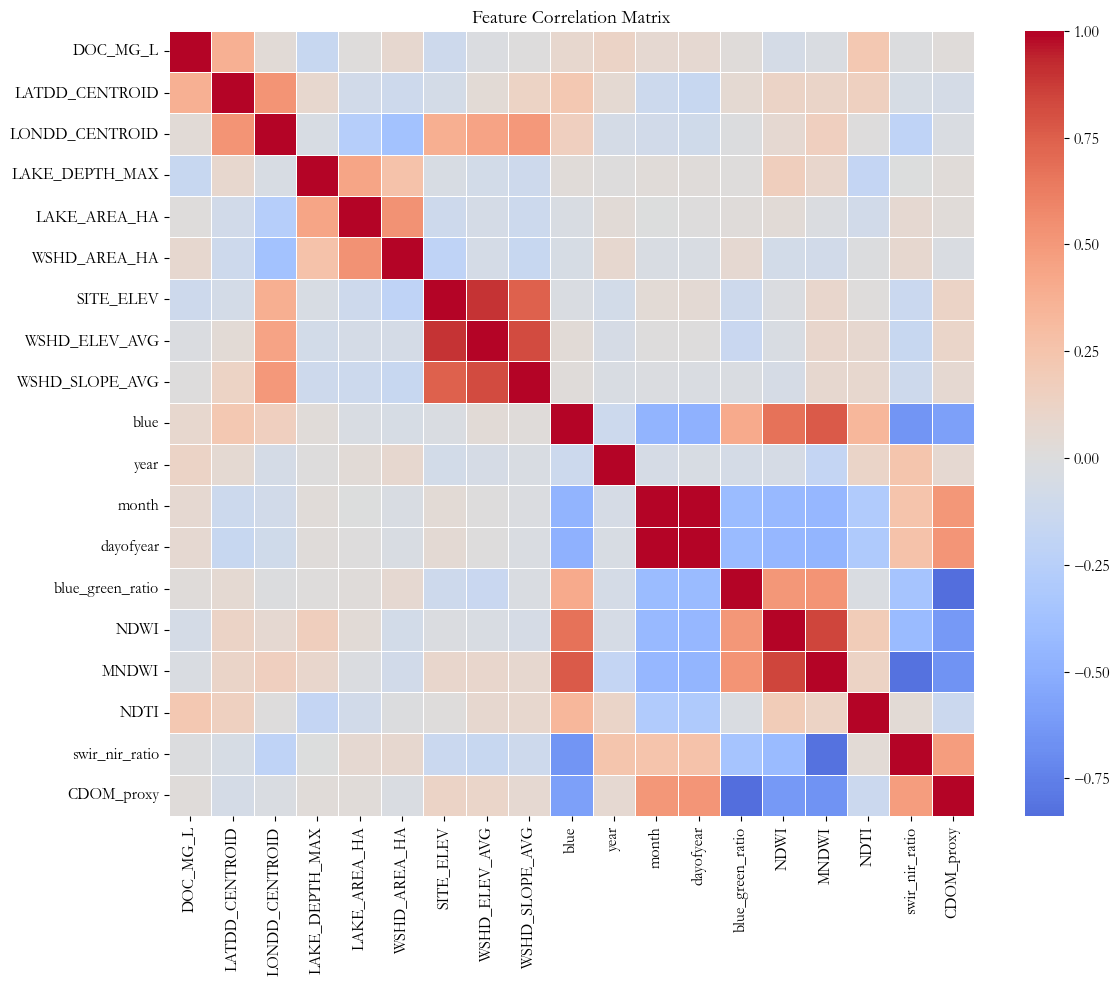

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only include numeric columns
corr_matrix = altm_sr_processed.select_dtypes(include='number').corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [91]:
# Get absolute correlations
abs_corr = corr_matrix.abs()

# Mask the diagonal and lower triangle
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

# Find pairs with correlation above threshold (e.g., 0.9)
high_corr = [(col, idx, upper.loc[idx, col])
             for col in upper.columns
             for idx in upper.index
             if pd.notnull(upper.loc[idx, col]) and abs(upper.loc[idx, col]) > 0.9]

# Display
for a, b, val in high_corr:
    print(f"{a} ↔ {b} = {val:.3f}")


dayofyear ↔ month = 0.996


In [92]:
altm_sr_processed.isna().sum()

SITE_ID             0
DOC_MG_L            0
SITE_NAME           0
LATDD_CENTROID      0
LONDD_CENTROID      0
LAKE_DEPTH_MAX      0
LAKE_AREA_HA        0
WSHD_AREA_HA        0
SITE_ELEV           0
WSHD_ELEV_AVG       0
WSHD_SLOPE_AVG      0
blue                0
year                0
month               0
dayofyear           0
blue_green_ratio    0
NDWI                0
MNDWI               0
NDTI                0
swir_nir_ratio      0
CDOM_proxy          0
dtype: int64

## Random Forest Model

Feature order used for training/testing:
['LAKE_DEPTH_MAX', 'LAKE_AREA_HA', 'WSHD_AREA_HA', 'SITE_ELEV', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG', 'blue', 'year', 'month', 'dayofyear', 'blue_green_ratio', 'NDWI', 'MNDWI', 'NDTI', 'swir_nir_ratio', 'CDOM_proxy']
📊 RMSE: 1.362
📈 R² Score: 0.559


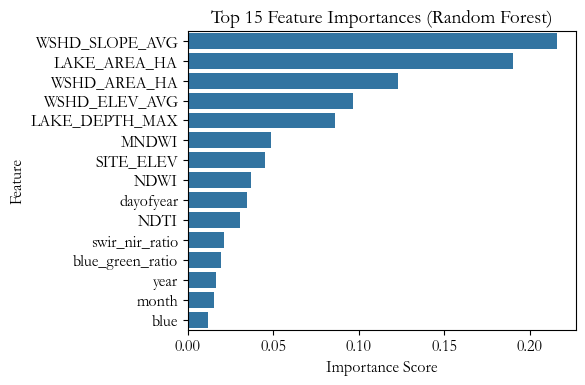

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# STEP 1: Prepare the data
# ---------------------------

# Make a copy to avoid modifying the original
df = altm_sr_processed.copy()

# Drop ID or descriptive columns not used in training
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])
# 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'blue_green_ratio', 'NDWI', 'MNDWI', 'CDOM_proxy', 'NDTI', 'NDVI',

# Separate features and target
X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

print("Feature order used for training/testing:")
print(list(X.columns))

# ---------------------------
# STEP 2: Train/Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# STEP 3: Train Random Forest
# ---------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ---------------------------
# STEP 4: Evaluate Performance
# ---------------------------

y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# ---------------------------
# STEP 5: Feature Importances
# ---------------------------

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 4))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


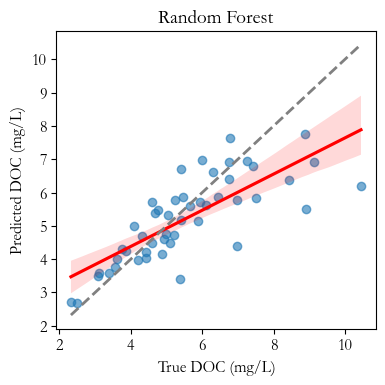

In [42]:
plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Random Forest")
plt.tight_layout()
plt.show()


Training models:   0%|                                                                           | 0/9 [00:00<?, ?it/s]

Random Forest - RMSE: 1.167, R²: 0.559


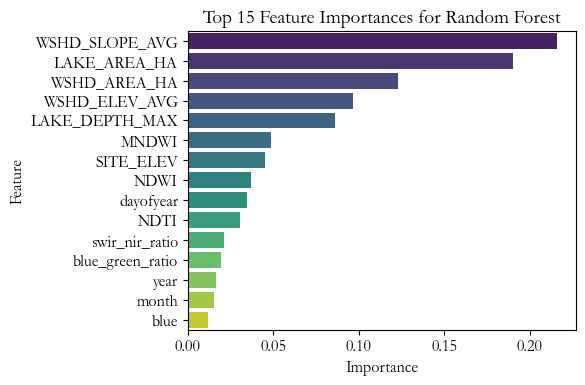

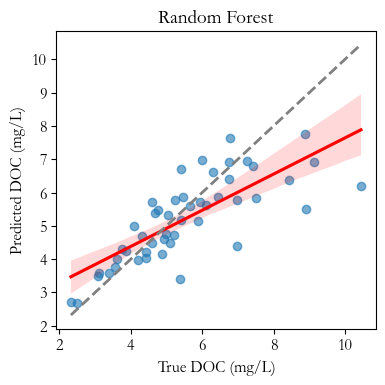

Training models:  11%|███████▍                                                           | 1/9 [00:01<00:12,  1.54s/it]

Gradient Boosting - RMSE: 1.001, R²: 0.676


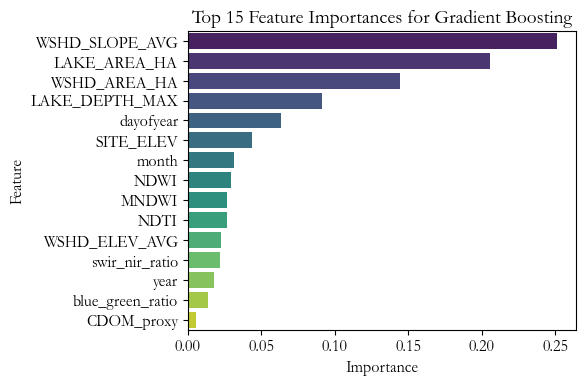

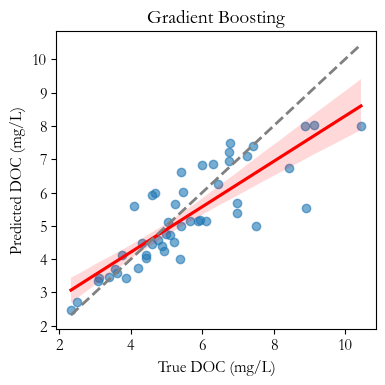

Training models:  22%|██████████████▉                                                    | 2/9 [00:03<00:11,  1.57s/it]

AdaBoost - RMSE: 1.222, R²: 0.517


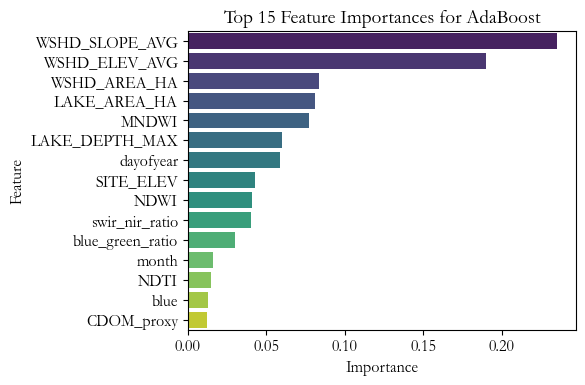

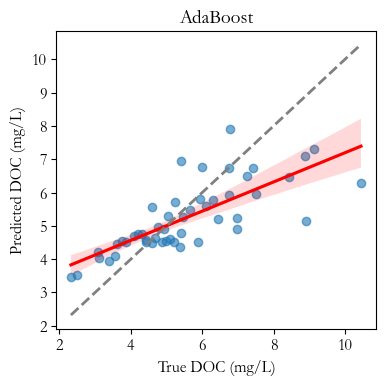

Training models:  33%|██████████████████████▎                                            | 3/9 [00:04<00:09,  1.64s/it]

Ridge - RMSE: 1.807, R²: -0.055


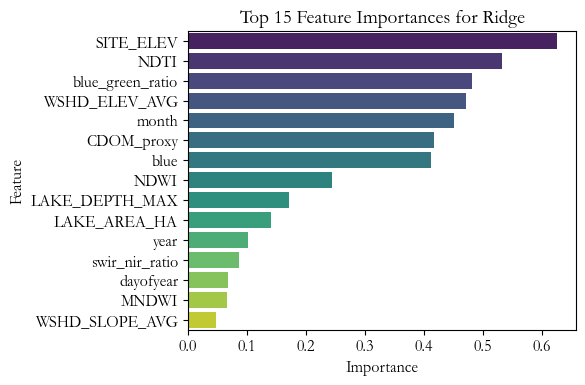

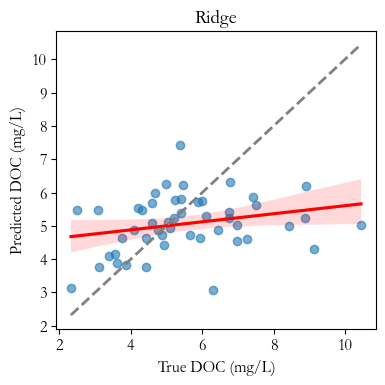

Training models:  44%|█████████████████████████████▊                                     | 4/9 [00:06<00:07,  1.56s/it]

Lasso - RMSE: 1.848, R²: -0.105


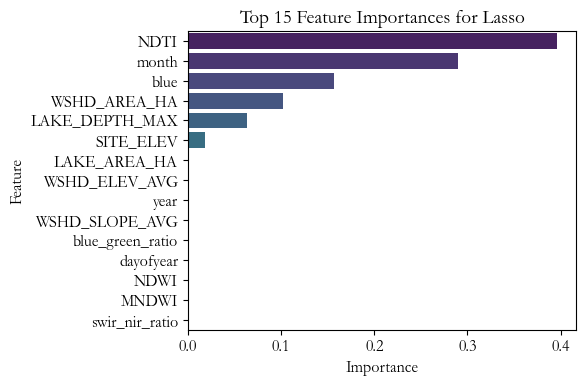

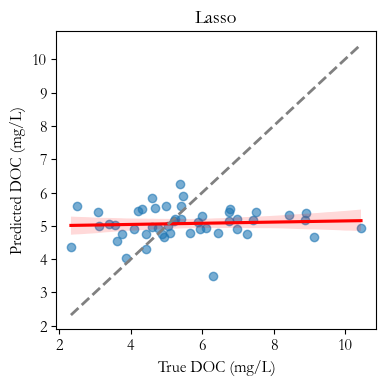

Training models:  56%|█████████████████████████████████████▏                             | 5/9 [00:07<00:05,  1.34s/it]

Decision Tree - RMSE: 1.789, R²: -0.035


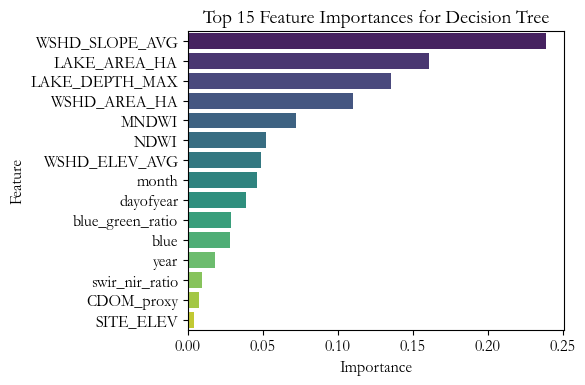

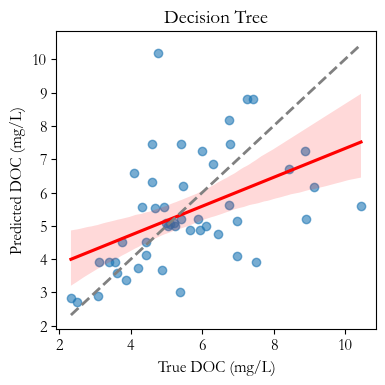

Training models:  67%|████████████████████████████████████████████▋                      | 6/9 [00:08<00:03,  1.18s/it]

SVR (RBF Kernel) - RMSE: 1.659, R²: 0.110


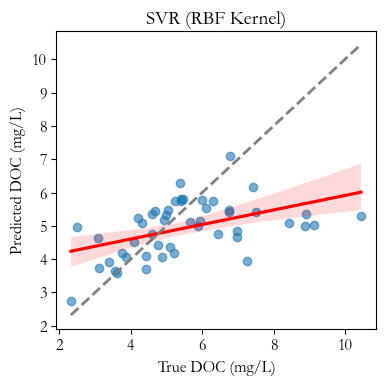

Training models:  78%|████████████████████████████████████████████████████               | 7/9 [00:08<00:01,  1.11it/s]

XGBoost - RMSE: 1.067, R²: 0.632


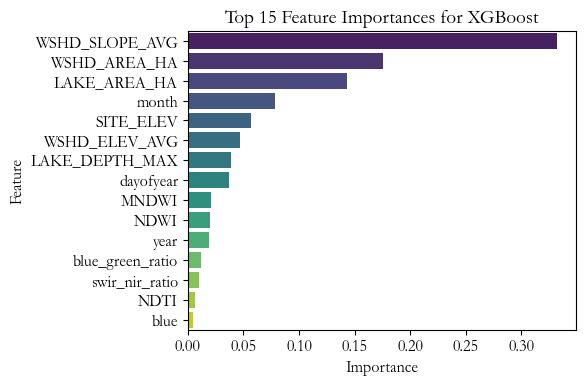

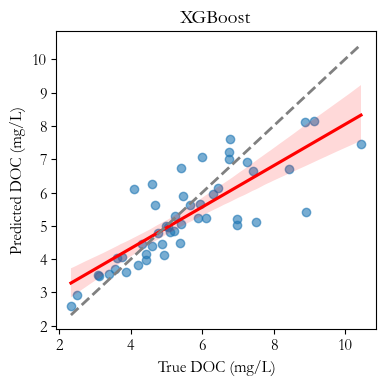

Training models:  89%|███████████████████████████████████████████████████████████▌       | 8/9 [00:10<00:01,  1.13s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 693
[LightGBM] [Info] Number of data points in the train set: 195, number of used features: 16
[LightGBM] [Info] Start training from score 5.126358
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

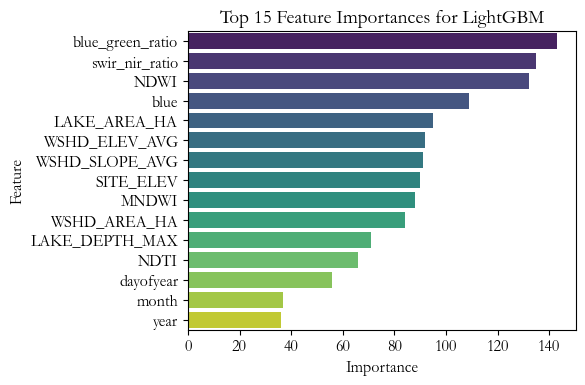

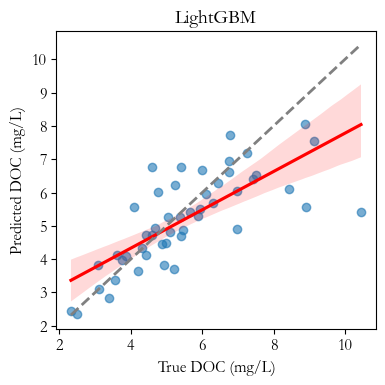

Training models: 100%|███████████████████████████████████████████████████████████████████| 9/9 [00:11<00:00,  1.24s/it]



Model Comparison:
               Model      RMSE        R2
1  Gradient Boosting  1.000592  0.676202
7            XGBoost  1.067211  0.631650
0      Random Forest  1.167247  0.559358
8           LightGBM  1.218053  0.520164
2           AdaBoost  1.221677  0.517305
6   SVR (RBF Kernel)  1.658886  0.109993
5      Decision Tree  1.788977 -0.035070
3              Ridge  1.806530 -0.055482
4              Lasso  1.848031 -0.104534


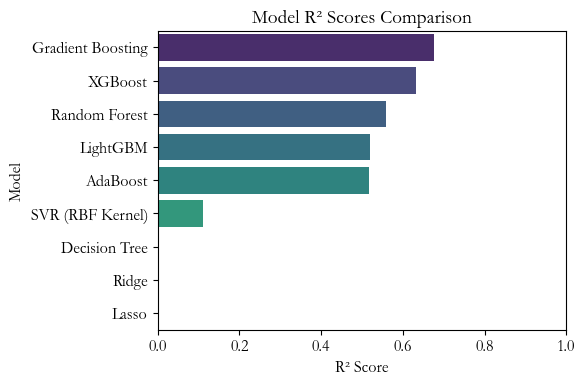

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# ---------------------------
# STEP 1: Prepare the data
# ---------------------------

df = altm_sr_processed.copy()

# Drop ID or descriptive columns not used in training
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

# Clean feature names (replace spaces with underscores)
X.columns = X.columns.str.replace(' ', '_')

# Convert boolean columns to integers (0/1)
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# ---------------------------
# STEP 2: Train/Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# STEP 3: Define models
# ---------------------------

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'SVR (RBF Kernel)': SVR(kernel='rbf', C=1.0, epsilon=0.2),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

# ---------------------------
# STEP 4: Train & Evaluate Models
# ---------------------------

results = []

for name in tqdm(models, desc="Training models"):
    model = models[name]
    model.fit(X_train, y_train)
    models[name] = model  # Save trained model back into the dictionary

    # import joblib

    # # Save only the AdaBoost model
    # if name == 'Gradient Boosting':
    #     joblib.dump(model, 'L8_gradientboosting_model_doc.pkl')

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name} - RMSE: {rmse:.3f}, R²: {r2:.3f}")

    # ---------------------------
    # Feature Importance Plot
    # ---------------------------
    
    # Some models have feature_importances_
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    # Linear models like Ridge and Lasso have coef_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
    else:
        importances = None

    if importances is not None:
        imp_df = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)
        plt.figure(figsize=(6, 4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f"Top 15 Feature Importances for {name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    # Scatterplot of True vs Predicted with regression line
    plt.figure(figsize=(4, 4))
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
    plt.xlabel("True DOC (mg/L)")
    plt.ylabel("Predicted DOC (mg/L)")
    plt.title(f"{name}")
    plt.tight_layout()
    plt.show()

# ---------------------------
# STEP 5: Results Summary
# ---------------------------

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("\nModel Comparison:")
print(results_df)

# Optional: plot the R2 scores for comparison
plt.figure(figsize=(6, 4))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title("Model R² Scores Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


📉 Stacking Regressor RMSE: 1.022
📈 Stacking Regressor R²: 0.670


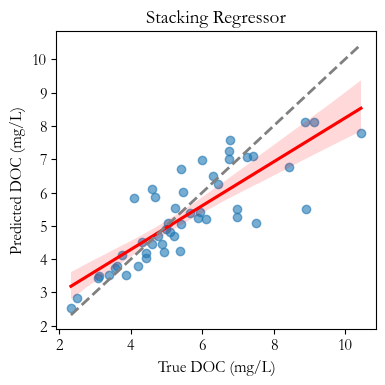

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Prepare data
# ---------------------------

df = altm_sr_processed.copy()
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

X.columns = X.columns.str.replace(' ', '_')

for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Define top models
# ---------------------------

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgbr = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

# ---------------------------
# Stacking Regressor
# ---------------------------

estimators = [
    ('gbr', gbr),
    ('xgb', xgbr)
]

# estimators = [
#     ('xgb', xgbr),
#     ('lgbm', lgbm)
# ]

stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

# Train stacking model
stacking_regressor.fit(X_train, y_train)
y_pred_stack = stacking_regressor.predict(X_test)
rmse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print(f"Stacking Regressor RMSE: {rmse_stack:.3f}")
print(f"Stacking Regressor R²: {r2_stack:.3f}")

# ---------------------------
# Scatterplot of True vs Predicted
# ---------------------------

plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred_stack, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred_stack))
max_val = max(max(y_test), max(y_pred_stack))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Stacking Regressor")
plt.tight_layout()
plt.show()

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 30.1772 - val_loss: 30.2080
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 25.6854 - val_loss: 26.8283
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 21.8232 - val_loss: 23.3752
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 18.0979 - val_loss: 19.1487
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 13.8034 - val_loss: 14.3733
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.3769 - val_loss: 9.9342
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.2461 - val_loss: 6.9440
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 4.7641 - val_loss: 5.9253
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7713 - val_loss: 5.6886
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.5726 - val_loss: 5.2915
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 3.7536 - val_loss: 5.0722
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.45

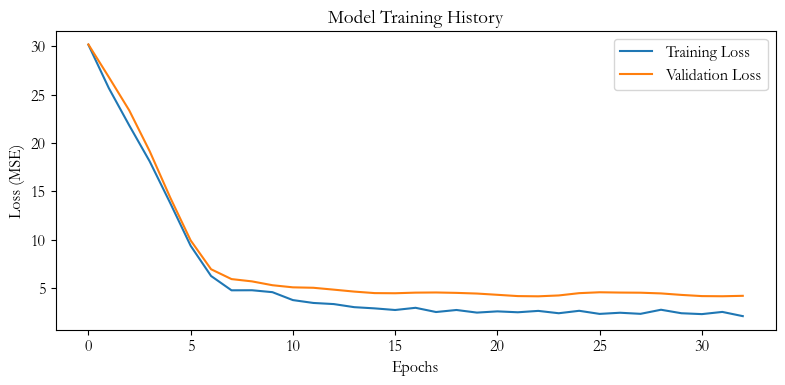

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------
# Prepare data
# ---------------------------

df = altm_sr_processed.copy()
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

# Clean feature names (just in case)
X.columns = X.columns.str.replace(' ', '_')

# Convert boolean columns to integers
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Define Neural Network
# ---------------------------

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

model.compile(optimizer='adam', loss='mse')

# ---------------------------
# Train Model
# ---------------------------

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# Evaluate Model
# ---------------------------

y_pred_nn = model.predict(X_test_scaled).flatten()
rmse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network RMSE: {rmse_nn:.3f}")
print(f"Neural Network R2: {r2_nn:.3f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Training History")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()


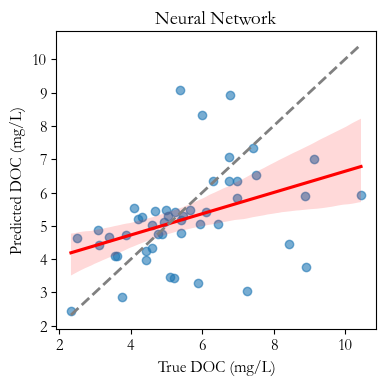

In [50]:
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred_nn, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred_nn))
max_val = max(max(y_test), max(y_pred_nn))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Neural Network")
plt.tight_layout()
plt.show()


In [51]:
# Identify the worst prediction
errors = np.abs(y_test - y_pred_nn)
worst_index = np.argmax(errors)

print(f"\nWorst prediction at index: {worst_index}")
print(f"True value: {y_test.iloc[worst_index]}")
print(f"Predicted: {y_pred_nn[worst_index]}")

# Optional: print input features for inspection
print("\nInput features for this sample:")
print(pd.Series(X_test.iloc[worst_index], index=X.columns))



Worst prediction at index: 3
True value: 8.9031
Predicted: 3.76082706451416

Input features for this sample:
LAKE_DEPTH_MAX     -0.458262
LAKE_AREA_HA       -0.471297
WSHD_AREA_HA       -0.266844
SITE_ELEV          -0.725972
WSHD_ELEV_AVG       0.347462
WSHD_SLOPE_AVG      1.176534
blue               -0.358554
year                0.384422
month               0.115252
dayofyear           0.020619
blue_green_ratio    0.375954
NDWI               -0.119795
MNDWI              -0.341551
NDTI                0.703348
swir_nir_ratio      0.404496
CDOM_proxy         -0.121571
Name: 218, dtype: float64


### Time-series (Using best model)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 693
[LightGBM] [Info] Number of data points in the train set: 195, number of used features: 16
[LightGBM] [Info] Start training from score 5.126358
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

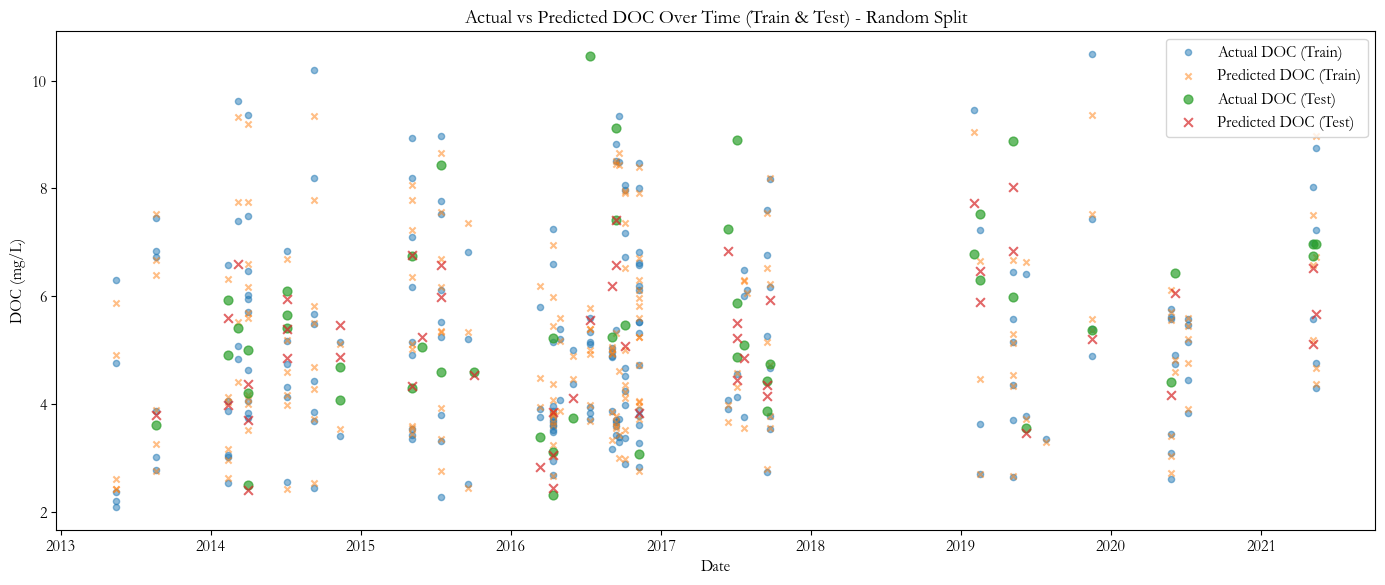

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb

# Prepare the data
df = altm_sr_processed.copy()
df['DATE_SMP'] = pd.to_datetime(altm_sr['DATE_SMP'])

# Define features and target
drop_cols = ['DOC_MG_L', 'SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID', 'DATE_SMP']
X = df.drop(columns=drop_cols)
y = df['DOC_MG_L']

# Random split (not temporal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Train LightGBM
model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Get corresponding dates for plotting
train_dates = df.loc[y_train.index, 'DATE_SMP']
test_dates = df.loc[y_test.index, 'DATE_SMP']

# Metrics
rmse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

rmse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {rmse_train:.3f}")
print(f"Train R²: {r2_train:.3f}")
print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test R²: {r2_test:.3f}")

# Scatterplot over time
plt.figure(figsize=(14, 6))

plt.scatter(train_dates, y_train, label='Actual DOC (Train)', alpha=0.5, s=20)
plt.scatter(train_dates, y_train_pred, label='Predicted DOC (Train)', alpha=0.5, s=20, marker='x')

plt.scatter(test_dates, y_test, label='Actual DOC (Test)', alpha=0.7, s=40)
plt.scatter(test_dates, y_test_pred, label='Predicted DOC (Test)', alpha=0.7, s=40, marker='x')

plt.xlabel('Date')
plt.ylabel('DOC (mg/L)')
plt.title('Actual vs Predicted DOC Over Time (Train & Test) - Random Split')
plt.legend()
plt.tight_layout()
plt.show()
